In [6]:
# Célula 1 — Imports e configuração de caminhos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_DIR  = BASE_DIR / 'data'
FIGURES_DIR = BASE_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
RED    = '#DC2626'
ORANGE = '#F59E0B'
GRAY   = '#64748B'

In [7]:
# Célula 2 — Carregar e preparar os dados
df = pd.read_csv(DATA_DIR / 'trec_2007.csv')

text_col  = [c for c in df.columns if 'text' in c.lower() or 'message' in c.lower() or 'body' in c.lower()][0]
label_col = [c for c in df.columns if 'label' in c.lower() or 'spam' in c.lower() or 'class' in c.lower()][0]

if df[label_col].dtype == object:
    df['label'] = df[label_col].map(
        lambda x: 1 if str(x).lower() in ['spam', '1'] else 0
    )
else:
    df['label'] = df[label_col]

df = df.dropna(subset=[text_col])
df['word_count'] = df[text_col].str.split().str.len()

mediana   = df['word_count'].median()
media     = df['word_count'].mean()
pct_acima = (df['word_count'] >= 150).mean() * 100
pct_abaixo = 100 - pct_acima
total     = len(df)
n_spam    = (df['label'] == 1).sum()
n_ham     = (df['label'] == 0).sum()

print(f"Total: {total:,} | Spam: {n_spam:,} | Ham: {n_ham:,}")
print(f"Mediana: {int(mediana)} | Média: {int(media)}")
print(f"≥ 150 palavras: {pct_acima:.1f}%")

Total: 73,932 | Spam: 48,714 | Ham: 25,218
Mediana: 192 | Média: 312
≥ 150 palavras: 59.5%


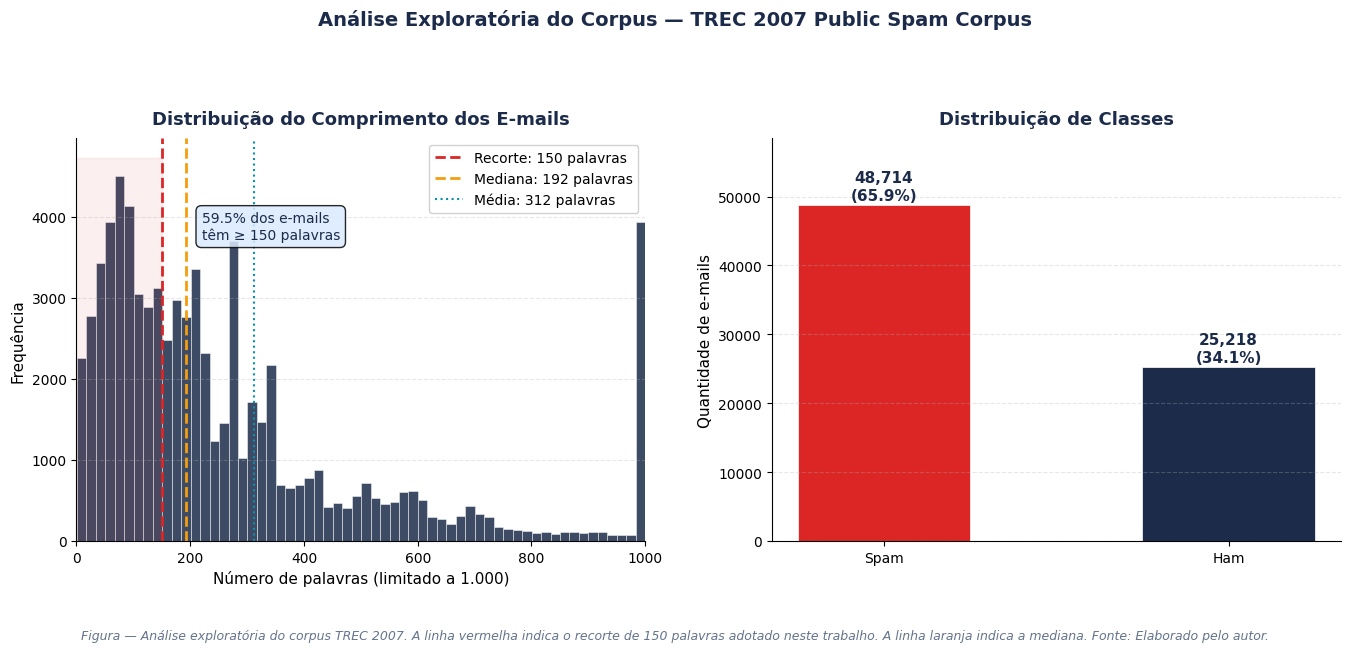


Figura salva em: /home/edson-luiz/Projetos/TCC/figures/exploratory_analysis_trec.png


In [8]:
# Célula 3 — Gerar figura com dois painéis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# ── AX1: Histograma do comprimento ───────────────────────────────────────────
ax1.hist(
    df['word_count'].clip(upper=1000),
    bins=60, color=NAVY, edgecolor='white', alpha=0.85, linewidth=0.4
)
ax1.axvline(x=150,     color=RED,    linestyle='--', linewidth=2.0,
            label=f'Recorte: 150 palavras')
ax1.axvline(x=mediana, color=ORANGE, linestyle='--', linewidth=2.0,
            label=f'Mediana: {int(mediana)} palavras')
ax1.axvline(x=media,   color=TEAL,   linestyle=':',  linewidth=1.5,
            label=f'Média: {int(media)} palavras')

ax1.fill_betweenx(
    [0, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 15000],
    0, 150, alpha=0.07, color=RED
)

ax1.annotate(
    f'{pct_acima:.1f}% dos e-mails\ntêm ≥ 150 palavras',
    xy=(220, ax1.get_ylim()[1] * 0.75 if ax1.get_ylim()[1] > 0 else 10000),
    fontsize=10, color=NAVY,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#DBEAFE', alpha=0.85)
)

ax1.set_title('Distribuição do Comprimento dos E-mails',
              fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax1.set_xlabel('Número de palavras (limitado a 1.000)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_xlim(0, 1000)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)

# ── AX2: Distribuição de classes ──────────────────────────────────────────────
classes  = ['Spam', 'Ham']
contagem = [n_spam, n_ham]
cores    = [RED, NAVY]
bars = ax2.bar(classes, contagem, color=cores, edgecolor='white',
               linewidth=0.5, width=0.5)

for bar, val in zip(bars, contagem):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{val:,}\n({val/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=11,
        fontweight='bold', color=NAVY
    )

ax2.set_title('Distribuição de Classes',
              fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax2.set_ylabel('Quantidade de e-mails', fontsize=11)
ax2.set_ylim(0, max(contagem) * 1.2)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)

# ── Título e rodapé ───────────────────────────────────────────────────────────
fig.suptitle(
    'Análise Exploratória do Corpus — TREC 2007 Public Spam Corpus',
    fontsize=14, fontweight='bold', color=NAVY, y=1.02
)
fig.text(
    0.5, -0.03,
    'Figura — Análise exploratória do corpus TREC 2007. '
    'A linha vermelha indica o recorte de 150 palavras adotado neste trabalho. '
    'A linha laranja indica a mediana. Fonte: Elaborado pelo autor.',
    ha='center', fontsize=9, color=GRAY, style='italic'
)

plt.tight_layout(pad=2.5)

# ── Salvar ────────────────────────────────────────────────────────────────────
output_path = FIGURES_DIR / 'exploratory_analysis_trec.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"\nFigura salva em: {output_path}")

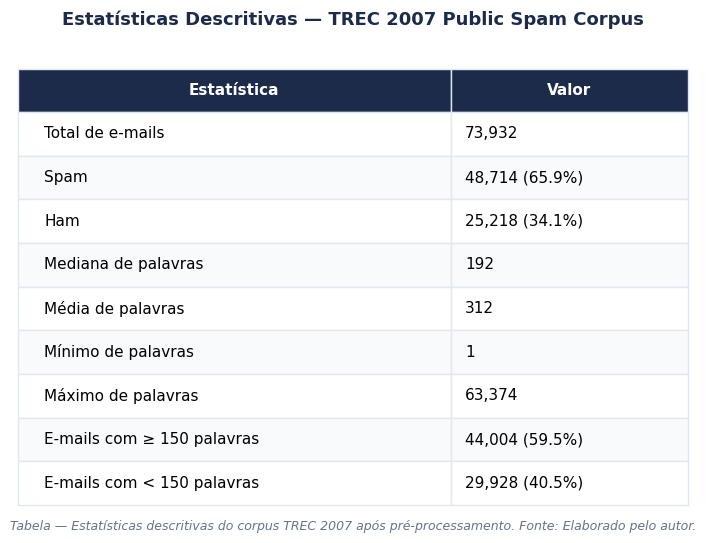

Tabela salva em: /home/edson-luiz/Projetos/TCC/figures/descriptive_stats_trec.png


In [10]:
# Célula 4 — Tabela de estatísticas descritivas
fig_tab, ax = plt.subplots(figsize=(7, 5))
fig_tab.patch.set_facecolor('white')
ax.axis('off')

q25    = df['word_count'].quantile(0.25)
q75    = df['word_count'].quantile(0.75)
maximo = df['word_count'].max()
minimo = df['word_count'].min()

dados_tabela = [
    ['Estatística',               'Valor'],
    ['Total de e-mails',          f'{total:,}'],
    ['Spam',                      f'{n_spam:,} ({n_spam/total*100:.1f}%)'],
    ['Ham',                       f'{n_ham:,} ({n_ham/total*100:.1f}%)'],
    ['Mediana de palavras',       f'{int(mediana)}'],
    ['Média de palavras',         f'{int(media)}'],
    ['Mínimo de palavras',        f'{int(minimo)}'],
    ['Máximo de palavras',        f'{int(maximo):,}'],
    ['E-mails com ≥ 150 palavras', f'{(df["word_count"]>=150).sum():,} ({pct_acima:.1f}%)'],
    ['E-mails com < 150 palavras', f'{(df["word_count"]<150).sum():,} ({pct_abaixo:.1f}%)'],
]

tabela = ax.table(
    cellText=dados_tabela[1:],
    colLabels=dados_tabela[0],
    cellLoc='left',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)

for (row, col), cell in tabela.get_celld().items():
    cell.set_edgecolor('#E2E8F0')
    cell.PAD = 0.06
    if row == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color='white', fontweight='bold')
    elif row in [10, 11]:
        cell.set_facecolor('#FEF2F2')
    elif row % 2 == 0:
        cell.set_facecolor('#F8FAFC')
    else:
        cell.set_facecolor('white')

tabela.auto_set_column_width([0, 1])

fig_tab.suptitle(
    'Estatísticas Descritivas — TREC 2007 Public Spam Corpus',
    fontsize=13, fontweight='bold', color=NAVY, y=1.02
)
fig_tab.text(
    0.5, -0.02,
    'Tabela — Estatísticas descritivas do corpus TREC 2007 após pré-processamento. '
    'Fonte: Elaborado pelo autor.',
    ha='center', fontsize=9, color=GRAY, style='italic'
)

plt.tight_layout()

output_path_tab = FIGURES_DIR / 'descriptive_stats_trec.png'
plt.savefig(output_path_tab, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Tabela salva em: {output_path_tab}")

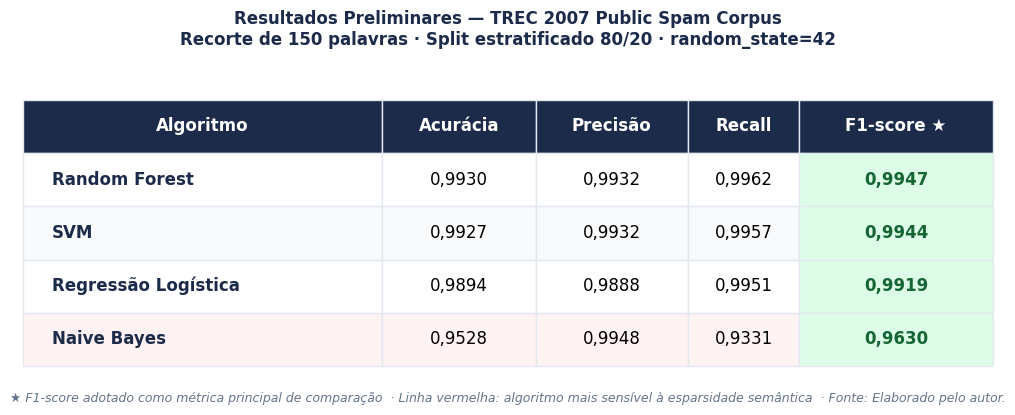

Tabela salva em: /home/edson-luiz/Projetos/TCC/figures/preliminary_results.png


In [11]:
# Célula — Tabela de resultados preliminares
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

BASE_DIR    = Path().resolve().parent
FIGURES_DIR = BASE_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

NAVY   = '#1C2B4A'
TEAL   = '#0891B2'
RED    = '#DC2626'
GRAY   = '#64748B'
BLUE   = '#DBEAFE'

# ── Dados dos resultados ──────────────────────────────────────────────────────
resultados = [
    ['Random Forest',       '0,9930', '0,9932', '0,9962', '0,9947'],
    ['SVM',                 '0,9927', '0,9932', '0,9957', '0,9944'],
    ['Regressão Logística', '0,9894', '0,9888', '0,9951', '0,9919'],
    ['Naive Bayes',         '0,9528', '0,9948', '0,9331', '0,9630'],
]
colunas = ['Algoritmo', 'Acurácia', 'Precisão', 'Recall', 'F1-score ★']

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
fig.patch.set_facecolor('white')
ax.axis('off')

tabela = ax.table(
    cellText=resultados,
    colLabels=colunas,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(12)

for (row, col), cell in tabela.get_celld().items():
    cell.set_edgecolor('#E2E8F0')
    cell.PAD = 0.08

    # Cabeçalho
    if row == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color='white', fontweight='bold')

    # Linhas de dados
    else:
        # Destaque na coluna F1-score (col 4)
        if col == 4:
            cell.set_facecolor('#DCFCE7')
            cell.set_text_props(fontweight='bold', color='#166534')
        # Linha do Naive Bayes (row 4) — mais sensível
        elif row == 4:
            cell.set_facecolor('#FEF2F2')
        # Linhas alternadas normais
        elif row % 2 == 0:
            cell.set_facecolor('#F8FAFC')
        else:
            cell.set_facecolor('white')

    # Coluna de algoritmos — alinhamento à esquerda
    if col == 0 and row > 0:
        cell.set_text_props(ha='left', fontweight='bold', color=NAVY)

tabela.auto_set_column_width([0, 1, 2, 3, 4])

# ── Título e rodapé ───────────────────────────────────────────────────────────
fig.suptitle(
    'Resultados Preliminares — TREC 2007 Public Spam Corpus\n'
    'Recorte de 150 palavras · Split estratificado 80/20 · random_state=42',
    fontsize=12, fontweight='bold', color=NAVY, y=1.06
)
fig.text(
    0.5, -0.06,
    '★ F1-score adotado como métrica principal de comparação  '
    '· Linha vermelha: algoritmo mais sensível à esparsidade semântica  '
    '· Fonte: Elaborado pelo autor.',
    ha='center', fontsize=9, color=GRAY, style='italic'
)

plt.tight_layout()

output_path = FIGURES_DIR / 'preliminary_results.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Tabela salva em: {output_path}")